# Sentiment analysis on movie reviews

In this notebook, we will explore basic NLP techniques to analyze movie reviews using the Large Movie Review Dataset, found in: https://ai.stanford.edu/~amaas/data/sentiment/

In [1]:
from collections import Counter

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords

import os

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
import re

In [2]:
def load_imdb_data(path):
    data = []
    labels = []
    for label in ['pos', 'neg']:
        dir_path = f"{path}/{label}"
        for filename in os.listdir(dir_path):
            with open(f"{dir_path}/{filename}", 'r', encoding='utf-8') as file:
                data.append(file.read())
                labels.append(1 if label == 'pos' else 0)
    return pd.DataFrame({'review': data, 'sentiment': labels})

In [3]:
# Change this to the path where you unzipped the dataset
dataset_root = "./datasets/movie-reviews/aclImdb"

train_df = load_imdb_data(dataset_root + "/train")
test_df = load_imdb_data(dataset_root + "/test")

## EDA

Let's take a quick look at the data to understand the distribution of sentiments, the length of reviews, and some common words used in positive vs negative reviews.

<Axes: xlabel='sentiment', ylabel='count'>

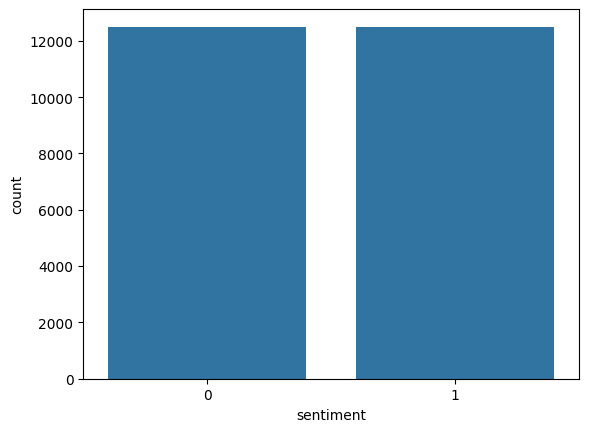

In [4]:
sns.countplot(x='sentiment', data=train_df)

As we can see, the dataset is balanced with an equal number of positive and negative reviews.

Let's now look at the distribution of review lengths. First compute the length of each review, both in terms of characters and words, and then plot the distributions.

In [5]:
n_chars = train_df['review'].apply(len)
n_words = train_df['review'].apply(lambda s: len(s.split()))

review_length_df = pd.DataFrame({'chars': n_chars, 'words': n_words, 'sentiment': train_df['sentiment']})
review_length_df.describe().T

,count,mean,std,min,25%,50%,75%,max
chars,25000.0,1325.06964,1003.133670,52.0,702.0,979.0,1614.0,13704.0
words,25000.0,233.78720,173.733032,10.0,127.0,174.0,284.0,2470.0
sentiment,25000.0,0.50000,0.500010,0.0,0.0,0.5,1.0,1.0


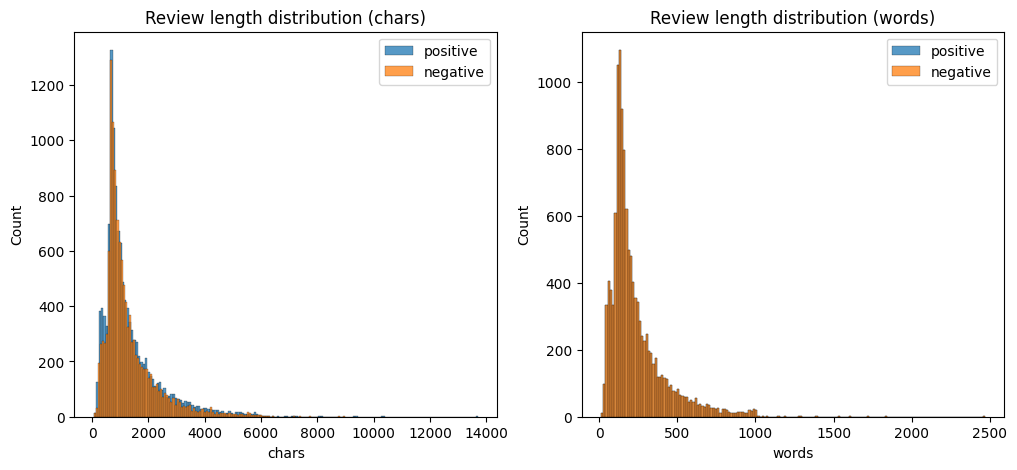

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(review_length_df[review_length_df['sentiment'] == 1]['chars'], ax=axs[0], label='positive')
sns.histplot(review_length_df[review_length_df['sentiment'] == 0]['chars'], ax=axs[0], label='negative')
axs[0].set_title("Review length distribution (chars)")
axs[0].legend()

sns.histplot(review_length_df[review_length_df['sentiment'] == 1]['words'], ax=axs[1], label='positive')
sns.histplot(review_length_df[review_length_df['sentiment'] == 1]['words'], ax=axs[1], label='negative')
axs[1].set_title("Review length distribution (words)")
axs[1].legend()

As can be seen, the distribution of review lengths is quite similar for both positive and negative reviews, with most reviews being below 500 words. In terms of characters, most reviews have less than 3000 characters. This can be confirmed with boxplots, which show the "whiskers" of the distribution and any potential outliers.

Text(0.5, 1.0, 'Review length (words) by sentiment')

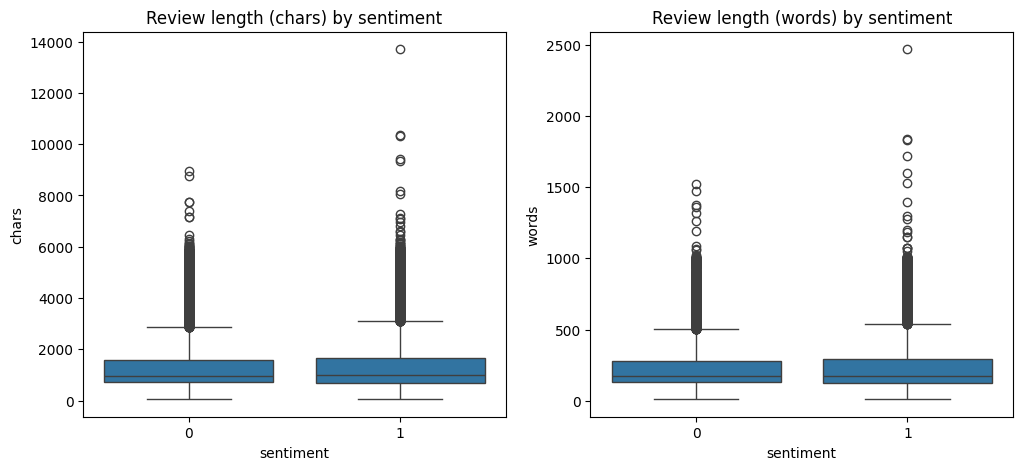

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='sentiment', y='chars', data=review_length_df, ax=axs[0])
axs[0].set_title("Review length (chars) by sentiment")

sns.boxplot(x='sentiment', y='words', data=review_length_df, ax=axs[1])
axs[1].set_title("Review length (words) by sentiment")

In [8]:
def get_top_words(docs, n=20):
    all_words = ' '.join(docs).split()
    count_by_word = Counter(all_words)
    return [w for w, i in count_by_word.most_common(n)]

In [9]:
print("Top words in positive reviews:")
print(get_top_words(train_df[train_df['sentiment'] == 1]['review']))

print("\nTop words in negative reviews:")
print(get_top_words(train_df[train_df['sentiment'] == 0]['review']))

Top words in positive reviews:
['the', 'and', 'a', 'of', 'to', 'is', 'in', 'that', 'I', 'it', 'this', '/><br', 'as', 'with', 'was', 'for', 'The', 'but', 'his', 'on']

Top words in negative reviews:
['the', 'a', 'and', 'of', 'to', 'is', 'in', 'I', 'that', 'this', 'it', '/><br', 'was', 'for', 'with', 'as', 'but', 'movie', 'The', 'on']


As we can see, the most common words in both positive and negative reviews are quite similar, with words like "the", "and", "a", "is" appearing frequently. Another issue is that this is case-insensitive, so "the" is treated as different that "The". To get a better idea of common words by sentiment, we can normalize the text by converting it to lowercase and removing any punctuation (and numbers, while we are at it).

In [10]:
def normalize_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [11]:
print("Top words in positive reviews (normalized):")
print(get_top_words([normalize_text(t) for t in train_df[train_df['sentiment'] == 1]['review']]))

print("\nTop words in negative reviews (normalized):")
print(get_top_words([normalize_text(t) for t in train_df[train_df['sentiment'] == 0]['review']]))

Top words in positive reviews (normalized):
['the', 'and', 'a', 'of', 'to', 'is', 'in', 'it', 'i', 'this', 'that', 'br', 'as', 'with', 'for', 'was', 'but', 'film', 'movie', 'his']

Top words in negative reviews (normalized):
['the', 'a', 'and', 'of', 'to', 'is', 'in', 'this', 'i', 'it', 'that', 'br', 'was', 'movie', 'for', 'but', 'with', 'as', 'film', 'on']


While most of the common words are still common stop words, at least we are now getting words like "movie" and "film". However, this still doesn't give us a good idea of which words are more associated with positive vs negative reviews.

To deal with this, we will use the NLTK library to remove stop words.

In [12]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /home/david/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [13]:
stopwords = stopwords.words('english')
print(stopwords)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

Some of these words are negations, such as "not", "no", "nor", which can be important for sentiment analysis. We will keep these in our list of stop words.

In [14]:
neg_words = [ 'no', 'nor', 'not', 'ain', 'aren', "aren't", 'don', "don't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'mightn', "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"]

stopwords = [w for w in stopwords if w not in neg_words]

Let's redefine our `get_top_words` function to remove stop words before counting the most common words.

In [15]:
def get_top_words(docs, n=20, exclude=None):
    all_words = ' '.join(docs).split()
    if exclude is not None:
        all_words = [w for w in all_words if w not in exclude]
    count_by_word = Counter(all_words)
    return [w for w, i in count_by_word.most_common(n)]

In [16]:
# Ensure stopwords are processed in the same way as our documents (lowercased and punctuation removed)
norm_stopwords = set([normalize_text(w) for w in stopwords])

print("Top words in positive reviews (no stopwords):")
print(get_top_words([normalize_text(t) for t in train_df[train_df['sentiment'] == 1]['review']], exclude=norm_stopwords))

print("\nTop words in negative reviews (no stopwords):")
print(get_top_words([normalize_text(t) for t in train_df[train_df['sentiment'] == 0]['review']], exclude=norm_stopwords))

Top words in positive reviews (no stopwords):
['br', 'film', 'movie', 'not', 'one', 'like', 'good', 'story', 'great', 'time', 'see', 'also', 'really', 'would', 'even', 'first', 'much', 'no', 'people', 'films']

Top words in negative reviews (no stopwords):
['br', 'movie', 'film', 'not', 'one', 'like', 'no', 'even', 'good', 'bad', 'would', 'really', 'time', 'see', 'dont', 'get', 'much', 'story', 'people', 'could']


We can now start to see some differences in the most common words between positive and negative reviews. Words like "good" and "great" are more common in positive reviews, while words like "bad" are now more common in negative reviews. That said, there is still a lot of overlap, since words like "movie", "film" and "story" are expected to appear in movie reviews regardless of the sentiment. We will deal with this later.

## Vectorization

We have now done some basic EDA to understand the data. The next step is to convert the text data into a format that can be used for machine learning models. One common approach is to use a bag-of-words representation, where we create a vector for each document that counts the occurrences of each word in the vocabulary. We can use the `CountVectorizer` from the `sklearn` library to do this.

In [17]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words=stopwords, lowercase=True)
x_train = vectorizer.fit_transform(train_df['review'])
x_test = vectorizer.transform(test_df['review'])

Now that we vectorized our text data, let's compare the result with the original text.

In [18]:
print(train_df['review'][0])
print(x_train[0])

Rock solid giallo from a master filmmaker of the genre, Sergio Martino. Fashioned from a marvelous screenplay by Ernesto Gestaldi, this shocking mystery often develops fascinating twists until the terrific finale which most might not see coming throughout the film. It's when everything has fallen into place that we can go, "Ahh.." The film revolves around the death of a husband(..in an airplane explosion)and the million dollars the wife receives from it. There are those with great interest in that money, one in particular being the dead man's mistress. The wife is Lisa(Ida Galli)and the mistress demanding half the money is Lara(Janine Reynaud). She tells Lisa she knows that the death was arranged by her to get the insurance money. Lara says she'll use her "lawyer", Sharif(Luis Barboo)to get that money. So already, the film produces two possible suspects in the later murder of Lisa, who awaiting someone in Tokyo. George Hilton portrays Peter Lynch. Peter works for a company that investi

We can see that the vectorizer converts every review into a sparse vector of word counts, where the length of the vector is equal to the size of the vocabulary (the number of unique words in the training set after removing stop words). The `fit_transform` method learns the vocabulary from the training data and transforms it into vectors, while the `transform` method uses the same vocabulary to transform the test data.

Each element in the vector corresponds to a word in the vocabulary, and the value of that element is the count of how many times that word appears in the review. Since most reviews will only contain a small subset of the total vocabulary, these vectors are typically very sparse (mostly zeros), which is why they are stored in a sparse format.

Let's get the list of words that are present in the first review and their corresponding counts.

In [19]:
vec = x_train[0].toarray()[0].tolist()
word_count = [(idx, count) for idx, count in enumerate(vec) if count > 0]
print(word_count)

[(2159, 1), (2268, 1), (2368, 1), (2808, 1), (2815, 1), (3365, 1), (3432, 1), (3705, 3), (3708, 1), (4286, 2), (4298, 1), (4642, 1), (4850, 1), (5219, 1), (5930, 1), (6871, 1), (7523, 1), (8703, 2), (8890, 1), (10256, 1), (11354, 1), (12779, 1), (13014, 2), (13504, 1), (13662, 1), (13764, 1), (13941, 1), (14073, 1), (15032, 1), (16341, 1), (16673, 1), (16722, 1), (16781, 2), (16908, 1), (17045, 1), (17306, 1), (17336, 1), (17384, 1), (18025, 1), (18486, 1), (19467, 2), (20061, 1), (20127, 1), (20476, 1), (21290, 1), (21785, 1), (22326, 1), (22739, 1), (22920, 1), (22977, 1), (23200, 1), (23497, 1), (23598, 1), (23604, 1), (23856, 1), (23867, 1), (24153, 1), (24504, 8), (24537, 1), (24577, 1), (24597, 1), (25321, 1), (25329, 2), (26548, 1), (26610, 1), (26884, 1), (27127, 1), (27186, 1), (27258, 1), (27269, 2), (27357, 1), (27359, 2), (27828, 1), (28060, 1), (28510, 1), (29467, 1), (29742, 1), (29866, 1), (30172, 1), (30956, 1), (31731, 1), (32146, 1), (32384, 1), (32411, 1), (33594, 1)

The previous cell gives us a list of tuples, where each tuple contains the index of a word in the vocabulary and the count of that word in the first review. To get the actual words, we can use the `get_feature_names_out` method of the vectorizer to get the list of words in the vocabulary and then map the indices to words.

In [20]:
for idx, count in word_count:
    print(f"{vectorizer.get_feature_names_out()[idx]}: {count}")

agent: 1
ahh: 1
airplane: 1
already: 1
also: 1
angles: 1
anita: 1
anyone: 3
anything: 1
around: 2
arranged: 1
assisting: 1
attacks: 1
awaiting: 1
barboo: 1
benton: 1
black: 1
br: 2
break: 1
camera: 1
certain: 1
clever: 1
cléo: 2
coming: 1
company: 1
complex: 1
conclusion: 1
confiscated: 1
could: 1
damage: 1
day: 1
dead: 1
death: 2
decides: 1
deeply: 1
delicious: 1
delivers: 1
demanding: 1
develops: 1
dinner: 1
dollars: 2
dressed: 1
driving: 1
dupont: 1
eliminating: 1
ends: 1
ernesto: 1
everything: 1
exciting: 1
execution: 1
explosion: 1
facts: 1
fall: 1
fallen: 1
fascinating: 1
fashioned: 1
felleghy: 1
film: 8
filmmaker: 1
finale: 1
find: 1
follow: 1
follows: 2
gain: 1
galli: 1
gathered: 1
genre: 1
george: 1
gestaldi: 1
get: 2
gialli: 1
giallo: 2
go: 1
goods: 1
great: 1
half: 1
happens: 1
harm: 1
head: 1
hilton: 1
hotel: 1
husband: 1
ida: 1
identity: 1
inheritance: 1
inspector: 1
insurance: 1
intent: 1
interest: 1
interpol: 1
investigates: 1
investigating: 1
investigation: 1
janine: 1


One problem with CountVectorizer is that it gives equal weight to all words, regardless of how common they are across the entire corpus. This can lead to issues where very common words (like "movie", "film", "story") dominate the representation, even though they may not be very informative for distinguishing between positive and negative reviews. To address this, we can use the `TfidfVectorizer`, which stands for Term Frequency-Inverse Document Frequency. This vectorizer gives more weight to words that are more unique to a particular document and less weight to words that are common across all documents.

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(stop_words=stopwords, lowercase=True)
x_train_tfidf = tfidf_vectorizer.fit_transform(train_df['review'])
x_test_tfidf = tfidf_vectorizer.transform(test_df['review'])

Now let's compare the TF-IDF representation with the original text and the CountVectorizer representation.

In [22]:
review_no_stopwords = ' '.join([w for w in train_df['review'][1].split() if w.lower() not in stopwords])
print("Original review:\n", train_df['review'][1])

print("\nOriginal review (no stopwords):\n", review_no_stopwords)

print("\nAs token IDs:\n", [vectorizer.vocabulary_.get(w.lower(), "-") for w in review_no_stopwords.split()])

Original review:
 The cast really helps make this a pleasant surprise and a cut above the normal man-vs.-woman-argue-all-the-time-but-wind up-in love-type of Hollywood screwball romance/comedy.<br /><br />I usually don't go for those type of films and that tiresome storyline but this one was refreshing, fun to watch, and oozes with charm.<br /><br />Jimmy Stewart and Margaret Sullavan play off each other well and make a very handsome couple. The supporting cast is outstanding - from the always-likable Felix Bressart to the villain Joseph Schildkraut. <br /><br />Frank Morgan also plays one of the most interesting characters I've ever seen him do in his career. He takes the film and turns it around into a whole different mood for awhile when something dramatic happens to him. That "twist" is another reason this film rises above others of its kind.<br /><br />Once again, when a film has a good mix of categories, it usually succeeds. This is a great example of that. In this movie, it's ro

## Training a model

Let's train a simple logistic regression model for this dataset.

To compare models fairly, we will keep the exact same logistic regression hyperparameters across all runs. Since reviews are loaded with all positives first and all negatives after, we will shuffle train/test once before running experiments so quick spot-checks are easier to interpret.

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

RANDOM_STATE = 42

# Ensures dataset is shuffled
train_exp_df = train_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
test_exp_df = test_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)


In [24]:
def run_experiment(vectorizer, preprocess_fn=None):
    train_text = train_exp_df['review']
    test_text = test_exp_df['review']

    if preprocess_fn is not None:
        train_text = train_text.apply(preprocess_fn)
        test_text = test_text.apply(preprocess_fn)

    x_train_vec = vectorizer.fit_transform(train_text)
    y_train = train_exp_df['sentiment']

    x_test_vec = vectorizer.transform(test_text)
    y_test = test_exp_df['sentiment']

    model = LogisticRegression(solver='liblinear', max_iter=1000, random_state=RANDOM_STATE)
    model.fit(x_train_vec, y_train)
    y_test_pred = model.predict(x_test_vec)
    y_train_pred = model.predict(x_train_vec)

    metrics = {
        'accuracy_train': accuracy_score(y_train, y_train_pred),
        'accuracy_test': accuracy_score(y_test, y_test_pred),
        'precision_train': precision_score(y_train, y_train_pred),
        'precision_test': precision_score(y_test, y_test_pred),
        'recall_train': recall_score(y_train, y_train_pred),
        'recall_test': recall_score(y_test, y_test_pred),
        'f1_train': f1_score(y_train, y_train_pred),
        'f1_test': f1_score(y_test, y_test_pred),
    }

    return model, vectorizer, metrics


In [25]:
experiments = [
    ('CountVectorizer', None, CountVectorizer(stop_words=stopwords, lowercase=True)),
    ('CountVectorizer-norm', normalize_text, CountVectorizer(stop_words=stopwords, lowercase=True)),
    ('TfidfVectorizer', None, TfidfVectorizer(stop_words=stopwords, lowercase=True)),
    ('TfidfVectorizer-norm', normalize_text, TfidfVectorizer(stop_words=stopwords, lowercase=True)),
]

results = []
model_runs = []
for exp_name, preprocess_fn, vectorizer in experiments:
    model, fitted_vectorizer, metrics = run_experiment(vectorizer, preprocess_fn=preprocess_fn)
    results.append({
        'vectorizer': exp_name,
        **metrics,
    })
    model_runs.append({
        'name': exp_name,
        'model': model,
        'fitted_vectorizer': fitted_vectorizer,
    })

results_df = pd.DataFrame(results).sort_values('accuracy_test', ascending=False)
results_df


,vectorizer,accuracy_train,accuracy_test,precision_train,precision_test,recall_train,recall_test,f1_train,f1_test
2,TfidfVectorizer,0.93652,0.88304,0.929950,0.883347,0.94416,0.88264,0.937001,0.882993
3,TfidfVectorizer-norm,0.93720,0.88224,0.931334,0.882730,0.94400,0.88160,0.937624,0.882165
1,CountVectorizer-norm,0.99892,0.86528,0.999040,0.871220,0.99880,0.85728,0.998920,0.864194
0,CountVectorizer,0.99832,0.86356,0.998480,0.869742,0.99816,0.85520,0.998320,0.862410


The table above compares all four configurations using the same logistic regression setup. You can use it to identify whether TF-IDF or CountVectorizer works better here, and whether applying `normalize_text` helps or hurts performance.



We can also look at the most important features for each model to see which words are driving the predictions. For logistic regression, we can look at the coefficients of the model to identify the most influential words for positive and negative sentiment.

As a reminder, a logistic regression model computes scores between 0 and 1 using a linear equation, where each feature has a coefficient. The higher the coefficient, the more that feature contributes to predicting the positive class (sentiment=1), while a lower coefficient contributes to predicting the negative class (sentiment=0). Since each feature represents a word in the vocabulary, we can look at the coefficients to see which words are most strongly associated with positive and negative reviews.

In [26]:
def get_top_features(model, fitted_vectorizer, top_n=10):
    feature_names = fitted_vectorizer.get_feature_names_out()
    coefs = model.coef_[0]

    top_pos_idx = coefs.argsort()[::-1][:top_n]
    top_neg_idx = coefs.argsort()[:top_n]

    top_positive = [(feature_names[idx], coefs[idx]) for idx in top_pos_idx]
    top_negative = [(feature_names[idx], coefs[idx]) for idx in top_neg_idx]
    return top_positive, top_negative

def print_compact_feature_table(model_runs, sentiment='positive', top_n=10):
    table_data = {}

    for run in model_runs:
        top_positive, top_negative = get_top_features(run['model'], run['fitted_vectorizer'], top_n=top_n)
        selected = top_positive if sentiment == 'positive' else top_negative
        table_data[run['name']] = [f"{word} ({coef:.3f})" for word, coef in selected]

    compact_df = pd.DataFrame(table_data, index=[f"#{i}" for i in range(1, top_n + 1)])
    compact_df.index.name = 'rank'
    display(compact_df)

print('Top 10 positive words across experiments')
print_compact_feature_table(model_runs, sentiment='positive', top_n=10)

print('\nTop 10 negative words across experiments')
print_compact_feature_table(model_runs, sentiment='negative', top_n=10)

Top 10 positive words across experiments


,CountVectorizer,CountVectorizer-norm,TfidfVectorizer,TfidfVectorizer-norm
rank,,,,
#1,refreshing (1.552),refreshing (1.626),great (7.241),great (7.296)
#2,wonderfully (1.494),wonderfully (1.455),excellent (6.169),excellent (6.250)
#3,funniest (1.350),funniest (1.376),best (5.193),best (5.278)
#4,superb (1.330),excellent (1.321),perfect (4.840),perfect (4.752)
#5,erotic (1.289),superb (1.308),wonderful (4.671),wonderful (4.648)
#6,excellent (1.282),erotic (1.307),well (4.447),well (4.209)
#7,perfect (1.272),flawless (1.278),amazing (4.227),favorite (4.190)
#8,surprisingly (1.252),perfect (1.220),love (4.059),amazing (4.172)
#9,carrey (1.244),hooked (1.216),favorite (4.057),love (4.104)



Top 10 negative words across experiments


,CountVectorizer,CountVectorizer-norm,TfidfVectorizer,TfidfVectorizer-norm
rank,,,,
#1,disappointment (-2.194),waste (-2.206),worst (-9.195),worst (-9.265)
#2,worst (-2.187),worst (-2.196),bad (-7.509),bad (-7.643)
#3,waste (-2.141),disappointment (-2.133),awful (-6.518),waste (-6.636)
#4,poorly (-1.792),poorly (-1.756),waste (-6.396),awful (-6.410)
#5,awful (-1.658),awful (-1.660),boring (-5.710),boring (-5.490)
#6,lacks (-1.612),lacks (-1.613),poor (-5.322),poor (-5.385)
#7,disappointing (-1.525),forgettable (-1.476),nothing (-4.839),nothing (-4.895)
#8,mess (-1.431),disappointing (-1.453),terrible (-4.783),terrible (-4.828)
#9,unfunny (-1.413),mstk (-1.444),worse (-4.662),worse (-4.702)


## Activity

#### Run 4 new experiments: 2 with CountVectorizer and 2 with TfidfVectorizer. For each vectorizer, apply stemming and lemmatization as the first step of your preprocessing function. Display the models metrics and top features as before.

In [27]:
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()
def stem_text(text):
    return ' '.join([stemmer.stem(w) for w in text.split()])

In [28]:
import spacy
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

def lem_text(text):
    doc = nlp(text)
    return ' '.join(token.lemma_ for token in doc)

In [29]:
experiments_act = [
    ('CountVectorizer-stem', stem_text, CountVectorizer(stop_words=stopwords, lowercase=True)),
    ('CountVectorizer-lem', lem_text, CountVectorizer(stop_words=stopwords, lowercase=True)),
    ('TfidfVectorizer-stem', stem_text, TfidfVectorizer(stop_words=stopwords, lowercase=True)),
    ('TfidfVectorizer-lem', lem_text, TfidfVectorizer(stop_words=stopwords, lowercase=True)),
]

results_act = []
model_runs_act = []

def experiment_loop(exp_name=None, preprocess_fn=None, vectorizer=None):
    print(exp_name)
    print(preprocess_fn)
    print(vec)
    model, fitted_vectorizer, metrics = run_experiment(vectorizer, preprocess_fn=preprocess_fn)
    results_act.append({
        'vectorizer': exp_name,
        **metrics,
    })
    model_runs_act.append({
        'name': exp_name,
        'model': model,
        'fitted_vectorizer': fitted_vectorizer,
    })


In [30]:
experiment_loop(*experiments_act[0])

CountVectorizer-stem
<function stem_text at 0x78e3ddbb7d80>
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [31]:
experiment_loop(*experiments_act[1])

CountVectorizer-lem
<function lem_text at 0x78e3d6771b20>
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [32]:
experiment_loop(*experiments_act[2])

TfidfVectorizer-stem
<function stem_text at 0x78e3ddbb7d80>
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [33]:
experiment_loop(*experiments_act[3])

TfidfVectorizer-lem
<function lem_text at 0x78e3d6771b20>
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [34]:
results_df = pd.DataFrame(results).sort_values('accuracy_test', ascending=False)
results_df

,vectorizer,accuracy_train,accuracy_test,precision_train,precision_test,recall_train,recall_test,f1_train,f1_test
2,TfidfVectorizer,0.93652,0.88304,0.929950,0.883347,0.94416,0.88264,0.937001,0.882993
3,TfidfVectorizer-norm,0.93720,0.88224,0.931334,0.882730,0.94400,0.88160,0.937624,0.882165
1,CountVectorizer-norm,0.99892,0.86528,0.999040,0.871220,0.99880,0.85728,0.998920,0.864194
0,CountVectorizer,0.99832,0.86356,0.998480,0.869742,0.99816,0.85520,0.998320,0.862410


In [35]:
print('Top 10 positive words across experiments')
print_compact_feature_table(model_runs, sentiment='positive', top_n=10)

print('\nTop 10 negative words across experiments')
print_compact_feature_table(model_runs, sentiment='negative', top_n=10)

Top 10 positive words across experiments


,CountVectorizer,CountVectorizer-norm,TfidfVectorizer,TfidfVectorizer-norm
rank,,,,
#1,refreshing (1.552),refreshing (1.626),great (7.241),great (7.296)
#2,wonderfully (1.494),wonderfully (1.455),excellent (6.169),excellent (6.250)
#3,funniest (1.350),funniest (1.376),best (5.193),best (5.278)
#4,superb (1.330),excellent (1.321),perfect (4.840),perfect (4.752)
#5,erotic (1.289),superb (1.308),wonderful (4.671),wonderful (4.648)
#6,excellent (1.282),erotic (1.307),well (4.447),well (4.209)
#7,perfect (1.272),flawless (1.278),amazing (4.227),favorite (4.190)
#8,surprisingly (1.252),perfect (1.220),love (4.059),amazing (4.172)
#9,carrey (1.244),hooked (1.216),favorite (4.057),love (4.104)



Top 10 negative words across experiments


,CountVectorizer,CountVectorizer-norm,TfidfVectorizer,TfidfVectorizer-norm
rank,,,,
#1,disappointment (-2.194),waste (-2.206),worst (-9.195),worst (-9.265)
#2,worst (-2.187),worst (-2.196),bad (-7.509),bad (-7.643)
#3,waste (-2.141),disappointment (-2.133),awful (-6.518),waste (-6.636)
#4,poorly (-1.792),poorly (-1.756),waste (-6.396),awful (-6.410)
#5,awful (-1.658),awful (-1.660),boring (-5.710),boring (-5.490)
#6,lacks (-1.612),lacks (-1.613),poor (-5.322),poor (-5.385)
#7,disappointing (-1.525),forgettable (-1.476),nothing (-4.839),nothing (-4.895)
#8,mess (-1.431),disappointing (-1.453),terrible (-4.783),terrible (-4.828)
#9,unfunny (-1.413),mstk (-1.444),worse (-4.662),worse (-4.702)


#### Which vectorizer and preprocessing combination gives the best performance? Do you see any interesting differences in the top features across the different models?

Remover la normalización y utilizar exclusivamente stemming y lematización como preprocesamiento realmente empeoró por un cierto grado de porcentaje, un 1% para ser preciso, el rendimiento de todos los modelos en test, mientras que en train se mantuvo prácticamente idéntico. Podemos notar algo muy necesario de señalar, que es el hecho de que Count Vectorizer en todos los casos presenta overfitting, mientras que TF-IDF Vectorizer en todas sus formas, aparte de ser prácticamente idéntico en exactitud, es el que menos overfitting presenta, entonces es el que yo considero mejor. Ahora bien, de todos, el mejor exactamente es el TF-IDF Vectorizer que no tiene ningún tipo de normalización en cuanto a exactitud. Sin embargo, podemos observar que las palabras que selecciona Count Vectorizer y TFIDF Vectorizer, en el caso sin ninguna función de preprocesamiento, pues no son necesariamente las mejores palabras. Vemos que al aplicar stemming y lematización, el conjunto de palabras seleccionadas para todos mejora bastante. O sea, pienso yo que great, excel, love y best son palabras más representativas de las emociones positivas, así como lo son excellent y flawless, aunque Count Vectorizer, cuando se le aplica exclusivamente stemming, mete palabras que no tienen nada que ver como units, squirrel y demás. Sin embargo, yo considero para encontrar los mejores términos el TFIDF Vectorizer con stemming. Y hay que detallar también que tanto stemming como lematización tardan demasiado para el prácticamente nulo nivel de mejora que tienen en este caso de aplicaciones específica.

#### Write a review for the latest movie that you have seen. Then, use the best performing model to predict the sentiment of your review. Do you agree with the model's prediction? Why or why not?

In [36]:
wayne_review = (pd.Series(["I loved the movie of Wayne's World as it portrayed very accurately the vibes of the young, and it really helped me understand what was the culturally most significant things in the 90s, epoch for which I am frankly fond of."]))
wayne_review = model_runs[2]['fitted_vectorizer'].transform(wayne_review)

wayne_pred = model_runs[2]['model'].predict(wayne_review)[0]

if wayne_pred:
    print("Positiva")
else:
    print("Negativa")

Positiva


Sí, estoy de acuerdo con la predicción del modelo. Siento que es tan preciso como puede llegar a ser, ya que, bueno, estoy influenciado, sesgado quizá, tras haber hecho esa actividad a utilizar ciertas palabras y no otras. Pero verdaderamente se trata de una condición natural del ser humano hablar con estas estos términos tan poderosos cuando algo es de su agrado o de su desagrado para esos efectos. Entonces, sí, estoy de acuerdo en que haya clasificado de forma positiva mi mi opinión, porque lo es, realmente lo es.

#### Write your final remarks on this activity.

Me resulta intrigante que los modelos de predicción de sentimiento sean tan buenos en distinguir críticas positivas de críticas negativas. Creo que empiezo a entender por qué y cómo es que de forma aparentemente objetiva, o al menos bajo consenso, las páginas de crítica pública a series y películas son capaces de emitir un veredicto final sin necesidad de, supongo, leer todas las críticas. Es grandioso, una lástima que se nos augurara que no vamos a volver a tocar estas características del aprendizaje de máquina.